In [1]:
import pandas as pd

df = pd.read_csv('amazon_delivery.csv')
df

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43734,jlxf819993117,30,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,11:35:00,11:45:00,Windy,High,motorcycle,Metropolitian,160,Home
43735,aevx342135787,21,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,19:55:00,20:10:00,Windy,Jam,motorcycle,Metropolitian,180,Jewelry
43736,xnek760674819,30,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,23:50:00,00:05:00,Cloudy,Low,scooter,Metropolitian,80,Home
43737,cynl434665991,20,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,13:35:00,13:40:00,Cloudy,High,motorcycle,Metropolitian,130,Kitchen


In [2]:
df = df.drop(['Order_ID', 'Pickup_Time'], axis=1)

In [3]:
import datetime as dt
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['day_of_week'] = df['Order_Date'].dt.dayofweek

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['month'] = df['Order_Date'].dt.month

df['Order_Time'] = pd.to_datetime(df['Order_Time'], format= '%H:%M:%S', errors='coerce')

df['hour'] = df['Order_Time'].dt.hour

df['order_hour_block'] = pd.cut(df['hour'], bins=[0, 6, 12, 18, 24], labels=('night', 'morning', 'afternoon', 'evening'))

df['is_fast_delivery'] = (df['Delivery_Time'] >= df['Delivery_Time'].median()).astype(int) 

## The columns 'Order_Date', and 'Date_time' served their purpose. Having successfuly extracted the needed information from those columns, I can drop them without hesitation.

In [4]:
df = df.drop(['Order_Date', 'Order_Time', 'hour', 'Delivery_Time'], axis=1)

In [5]:
df.head()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Weather,Traffic,Vehicle,Area,Category,day_of_week,is_weekend,month,order_hour_block,is_fast_delivery
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,motorcycle,Urban,Clothing,5,1,3,morning,0
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,scooter,Metropolitian,Electronics,4,0,3,evening,1
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,motorcycle,Urban,Sports,5,1,3,morning,1
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,motorcycle,Metropolitian,Cosmetics,1,0,4,afternoon,0
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,scooter,Metropolitian,Toys,5,1,3,afternoon,1


In [6]:
df.nunique()

Agent_Age             22
Agent_Rating          28
Store_Latitude       521
Store_Longitude      415
Drop_Latitude       4367
Drop_Longitude      4367
Weather                6
Traffic                5
Vehicle                4
Area                   4
Category              16
day_of_week            7
is_weekend             2
month                  3
order_hour_block       3
is_fast_delivery       2
dtype: int64

In [7]:
onehot_cols =['Weather', 'Traffic', 'Vehicle', 'Area', 'order_hour_block']
target_cols = ['Category']
num_cols = ['Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'day_of_week', 'is_weekend', 'month']
df.shape

(43739, 16)

In [8]:
print(set(df.drop('is_fast_delivery', axis=1).columns) - set(num_cols) - set(onehot_cols) - set(target_cols))

{'Drop_Latitude', 'Drop_Longitude'}


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('is_fast_delivery', axis=1)
y = df['is_fast_delivery']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

num_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_preprocessor, num_cols),
    ('onehot', OneHotEncoder(), onehot_cols), 
    ('target', TargetEncoder(), target_cols)
], remainder='passthrough')

xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', XGBClassifier(reg_lambda=2, reg_alpha=0, max_depth=3, learning_rate=0.1, n_jobs=-1, random_state=42))
])

xgb_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [11]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

params = {
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],  
    'model__reg_lambda': [0, 2, 3, 5], 
    'model__reg_alpha': [0, 2, 3, 5], 
    'model__max_depth': [3, 5, 7], 
    'preprocessor__target__smooth': [0.1, 1.0, 10.0, 50.0]
}
xgb_search = HalvingRandomSearchCV(
    estimator=xgb_pipe,cv=5,verbose=1, param_distributions=params, 
)
xgb_search.fit(X_train, y_train)

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 20
max_resources_: 34991
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 768
n_resources: 20
Fitting 5 folds for each of 768 candidates, totalling 3840 fits


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 768 is smaller than n_iter=1749. Running 768 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


----------
iter: 1
n_candidates: 256
n_resources: 60
Fitting 5 folds for each of 256 candidates, totalling 1280 fits


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\pipeline.py", line 1131, in score
    Xt = transform.transform(Xt)
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f

----------
iter: 2
n_candidates: 86
n_resources: 180
Fitting 5 folds for each of 86 candidates, totalling 430 fits


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\pipeline.py", line 1131, in score
    Xt = transform.transform(Xt)
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f

----------
iter: 3
n_candidates: 29
n_resources: 540
Fitting 5 folds for each of 29 candidates, totalling 145 fits


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\pipeline.py", line 1131, in score
    Xt = transform.transform(Xt)
  File "C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f

----------
iter: 4
n_candidates: 10
n_resources: 1620
Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.61666667 0.55       0.61666667 ... 0.77537362 0.78156366 0.78280587]
  warnings.warn(


----------
iter: 5
n_candidates: 4
n_resources: 4860
Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.61666667 0.55       0.61666667 ... 0.80889859 0.80807449 0.80725144]
  warnings.warn(


----------
iter: 6
n_candidates: 2
n_resources: 14580
Fitting 5 folds for each of 2 candidates, totalling 10 fits


C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.61666667 0.55       0.61666667 ... 0.80725144 0.81147082 0.80865838]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 5, ...], 'model__reg_alpha': [0, 2, ...], 'model__reg_lambda': [0, 2, ...], ...}"
,"n_candidates n_candidates: ""exhaust"" or int, default=""exhaust""The number of candidate parameters to sample, at the firstiteration. Using 'exhaust' will sample enough candidates so that thelast iteration uses as many resources as possible, based on`min_resources`, `max_resources` and `factor`. In this case,`min_resources` cannot be 'exhaust'.",'exhaust'
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_samples'
,"max_resources max_resources: int, default='auto'The maximum number of resources that any candidate is allowed to usefor a given iteration. By default, this is set ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",'auto'
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='smallest'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming. 'exhaust' isn't available when `n_candidates='exhaust'`.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",'smallest'
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or an iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the 

In [12]:
print(xgb_search.best_params_)

{'preprocessor__target__smooth': 0.1, 'model__reg_lambda': 2, 'model__reg_alpha': 0, 'model__max_depth': 5, 'model__learning_rate': 0.05}


In [13]:
best_model = xgb_search.best_estimator_

best_model_train_score = xgb_search.score(X_train, y_train)
best_model_test_score = xgb_search.score(X_test, y_test)
 
print(f'train score: {best_model_train_score}')
print(f'test score: {best_model_test_score}')

train score: 0.8175530850790204
test score: 0.8078417924096937


In [14]:
best_model_pred = best_model.predict_proba(X_test)
y_proba = best_model_pred[:, 1]
y_proba = (y_proba >= 0.5).astype(int)


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_proba))
print(confusion_matrix(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.79      0.83      0.81      4269
           1       0.83      0.79      0.81      4479

    accuracy                           0.81      8748
   macro avg       0.81      0.81      0.81      8748
weighted avg       0.81      0.81      0.81      8748

[[3547  722]
 [ 959 3520]]


In [18]:
y_proba_04 = (y_proba >= 0.4).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(classification_report(y_test, y_proba_04))
print(confusion_matrix(y_test, y_proba_04))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81      4269
           1       0.83      0.79      0.81      4479

    accuracy                           0.81      8748
   macro avg       0.81      0.81      0.81      8748
weighted avg       0.81      0.81      0.81      8748

[[3547  722]
 [ 959 3520]]


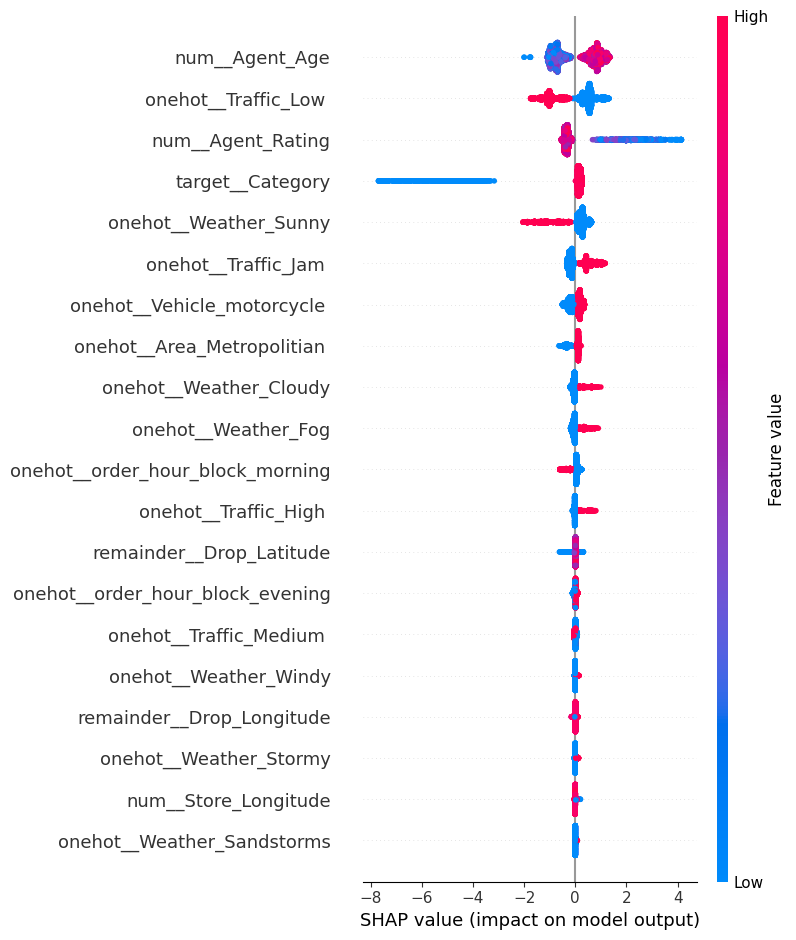

In [21]:
from shap import TreeExplainer, summary_plot

extracted_model = best_model.named_steps['model']
X_test_prepped = best_model.named_steps['preprocessor'].transform(X_test)
feature_names = preprocessor.get_feature_names_out()

explainer = TreeExplainer(extracted_model)
shap_values = explainer.shap_values(X_test_prepped)

summary_plot(shap_values, X_test_prepped, feature_names=feature_names)

In [22]:
import joblib as jl 

jl.dump(best_model, 'best_model.pkl')


['best_model.pkl']

In [23]:
jl.load('best_model.pkl')

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 